# Train Itay LoRA - Steps 1 and 2

This notebook prepares the `Itay/` dataset, trains a low-rank LoRA for the trigger token `itayperson`, generates validation samples, and computes CLIP-I / CLIP-T metrics.

Run the cells from top to bottom. Source images are never modified; generated artifacts are written under `outputs/`.

## 0. Dependency Check

Install dependencies once with `pip install -r requirements.txt` before running the training cells.

In [1]:
import importlib.util
from pathlib import Path

required_modules = [
    'accelerate',
    'diffusers',
    'peft',
    'PIL',
    'safetensors',
    'torch',
    'torchvision',
    'tqdm',
    'transformers',
]

missing_modules = [name for name in required_modules if importlib.util.find_spec(name) is None]
if missing_modules:
    raise RuntimeError(
        'Missing dependencies: ' + ', '.join(missing_modules) +
        '. Run: pip install -r requirements.txt'
    )

print('Dependencies OK')

Dependencies OK


## 1. Imports and Configuration

In [2]:
import csv
import json
import math
import os
import random
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Iterable

os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import torch
import torch.nn.functional as F
from diffusers import AutoencoderKL, DDPMScheduler, StableDiffusionPipeline, UNet2DConditionModel
from diffusers.optimization import get_scheduler
from diffusers.utils import convert_state_dict_to_diffusers
from IPython.display import display
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict
from PIL import Image, ImageOps
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm
from transformers import CLIPModel, CLIPProcessor, CLIPTextModel, CLIPTokenizer

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp'}


def read_env_file(path: Path) -> dict[str, str]:
    values: dict[str, str] = {}
    if not path.exists():
        return values
    for raw_line in path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        values[key.strip()] = value.strip().strip('"').strip("'")
    return values


env_values = read_env_file(Path('config.env'))


def config_value(name: str, default: str) -> str:
    return os.getenv(name, env_values.get(name, default))


@dataclass(frozen=True)
class TrainingConfig:
    model_id: str = config_value('SD_MODEL_ID', 'runwayml/stable-diffusion-v1-5')
    dataset_dir: Path = Path(config_value('DATASET_DIR', 'Itay'))
    prepared_dir: Path = Path(config_value('PREPARED_DIR', 'outputs/prepared'))
    lora_dir: Path = Path(config_value('LORA_DIR', 'outputs/lora'))
    samples_dir: Path = Path(config_value('SAMPLES_DIR', 'outputs/samples'))
    metrics_dir: Path = Path(config_value('METRICS_DIR', 'outputs/metrics'))
    trigger_token: str = config_value('TRIGGER_TOKEN', 'itayperson')
    resolution: int = int(config_value('RESOLUTION', '512'))
    rank: int = int(config_value('LORA_RANK', '8'))
    alpha: int = int(config_value('LORA_ALPHA', '8'))
    batch_size: int = int(config_value('TRAIN_BATCH_SIZE', '1'))
    max_train_steps: int = int(config_value('MAX_TRAIN_STEPS', '1000'))
    learning_rate: float = float(config_value('LEARNING_RATE', '1e-4'))
    validation_steps: int = int(config_value('VALIDATION_STEPS', '30'))
    lora_scale: float = float(config_value('LORA_SCALE', '0.8'))
    seed: int = int(config_value('SEED', '42'))


config = TrainingConfig()
for output_dir in [config.prepared_dir, config.lora_dir, config.samples_dir, config.metrics_dir]:
    output_dir.mkdir(parents=True, exist_ok=True)

random.seed(config.seed)
torch.manual_seed(config.seed)
if hasattr(torch, 'set_float32_matmul_precision'):
    torch.set_float32_matmul_precision('high')

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
weight_dtype = torch.float16 if device.type == 'cuda' else torch.float32

print(json.dumps({**asdict(config), 'device': str(device), 'weight_dtype': str(weight_dtype)}, indent=2, default=str))

/Users/tun/Documents/ZenAI/Training-ZenAI-Phase2/Finetune SD + Inference with ComfyUI/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{
  "model_id": "runwayml/stable-diffusion-v1-5",
  "dataset_dir": "Itay",
  "prepared_dir": "outputs/prepared",
  "lora_dir": "outputs/lora",
  "samples_dir": "outputs/samples",
  "metrics_dir": "outputs/metrics",
  "trigger_token": "itayperson",
  "resolution": 512,
  "rank": 8,
  "alpha": 8,
  "batch_size": 1,
  "max_train_steps": 1600,
  "learning_rate": 0.0001,
  "validation_steps": 30,
  "lora_scale": 1.0,
  "seed": 42,
  "device": "mps",
  "weight_dtype": "torch.float32"
}


## 2. Prepare Dataset

This cell fixes EXIF orientation, strips metadata, center-crops, resizes to 512x512, and writes one caption per image.

In [3]:
def list_source_images(dataset_dir: Path) -> list[Path]:
    if not dataset_dir.exists():
        raise FileNotFoundError(f'Missing dataset directory: {dataset_dir}')
    images = sorted(
        path for path in dataset_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )
    if not images:
        raise RuntimeError(f'No images found in {dataset_dir}')
    return images


def center_crop_square(image: Image.Image) -> Image.Image:
    width, height = image.size
    side = min(width, height)
    left = (width - side) // 2
    top = (height - side) // 2
    return image.crop((left, top, left + side, top + side))


def prepare_image(source_path: Path, destination_path: Path, resolution: int) -> None:
    with Image.open(source_path) as image:
        image = ImageOps.exif_transpose(image).convert('RGB')
        image = center_crop_square(image)
        image = image.resize((resolution, resolution), Image.Resampling.LANCZOS)
        image.save(destination_path, format='JPEG', quality=95, optimize=True)


def write_caption(destination_path: Path, trigger_token: str) -> None:
    caption = f'photo of {trigger_token}'
    destination_path.write_text(caption + '\n', encoding='utf-8')


def prepare_dataset(config: TrainingConfig, overwrite: bool = True) -> list[Path]:
    source_images = list_source_images(config.dataset_dir)
    prepared_images: list[Path] = []
    for index, source_path in enumerate(source_images):
        stem = f'{config.trigger_token}_{index:03d}'
        image_path = config.prepared_dir / f'{stem}.jpg'
        caption_path = config.prepared_dir / f'{stem}.txt'
        if overwrite or not image_path.exists():
            prepare_image(source_path, image_path, config.resolution)
        if overwrite or not caption_path.exists():
            write_caption(caption_path, config.trigger_token)
        prepared_images.append(image_path)
    return prepared_images


prepared_images = prepare_dataset(config, overwrite=False)
print(f'Prepared {len(prepared_images)} images in {config.prepared_dir}')

Prepared 22 images in outputs/prepared


## 3. Validate and Review Captions

Dataset OK: 22 prepared images


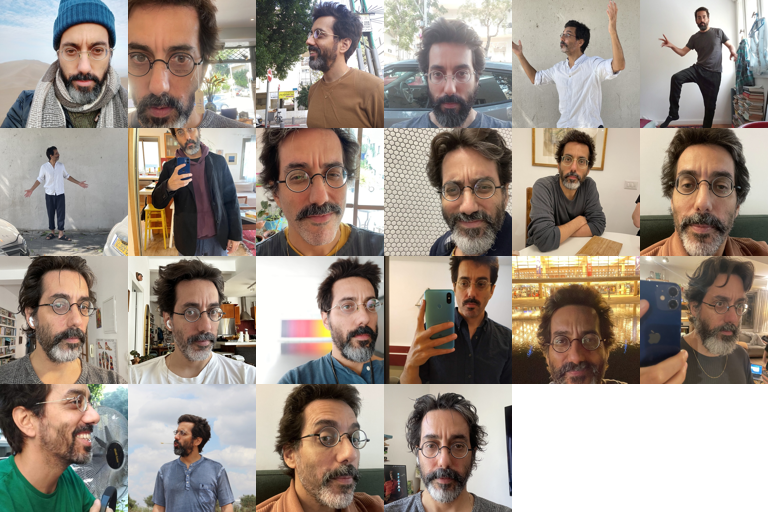

itayperson_000.jpg: photo of itayperson, an adult man with round glasses, dark messy hair, and a salt and pepper beard, wearing a blue knit beanie and gray scarf outdoors in a desert landscape
itayperson_001.jpg: close-up photo of itayperson, an adult man with round glasses, dark messy hair, thick eyebrows, and a salt and pepper beard, indoors near a bright window
itayperson_002.jpg: side profile photo of itayperson, an adult man with round glasses, dark messy hair, and a salt and pepper beard, smiling outdoors on a city street
itayperson_003.jpg: front-facing selfie photo of itayperson, an adult man with round glasses, dark messy hair, thick eyebrows, and a full dark beard with gray, outdoors near parked cars
itayperson_004.jpg: upper body photo of itayperson, an adult man with round glasses, short dark hair, and a trimmed salt and pepper beard, wearing a white shirt and gesturing with raised arms against a plain wall


In [4]:
def validate_prepared_dataset(config: TrainingConfig) -> list[Path]:
    images = sorted(config.prepared_dir.glob('*.jpg'))
    errors: list[str] = []
    for image_path in images:
        caption_path = image_path.with_suffix('.txt')
        if not caption_path.exists():
            errors.append(f'Missing caption: {caption_path}')
            continue
        caption = caption_path.read_text(encoding='utf-8').strip()
        if config.trigger_token not in caption:
            errors.append(f'Caption missing trigger token: {caption_path}')
        with Image.open(image_path) as image:
            if image.size != (config.resolution, config.resolution):
                errors.append(f'Unexpected image size for {image_path}: {image.size}')
            if image.getexif():
                errors.append(f'EXIF still present: {image_path}')
    if errors:
        raise RuntimeError('\n'.join(errors))
    return images


def make_contact_sheet(image_paths: list[Path], thumb_size: int = 128, columns: int = 6) -> Image.Image:
    rows = math.ceil(len(image_paths) / columns)
    sheet = Image.new('RGB', (columns * thumb_size, rows * thumb_size), 'white')
    for index, image_path in enumerate(image_paths):
        with Image.open(image_path) as image:
            thumb = image.convert('RGB').resize((thumb_size, thumb_size))
        x = (index % columns) * thumb_size
        y = (index // columns) * thumb_size
        sheet.paste(thumb, (x, y))
    return sheet


validated_images = validate_prepared_dataset(config)
print(f'Dataset OK: {len(validated_images)} prepared images')
display(make_contact_sheet(validated_images))

for image_path in validated_images[:5]:
    print(f'{image_path.name}: {image_path.with_suffix(".txt").read_text(encoding="utf-8").strip()}')

## 4. Training Dataset and Model Loading

In [5]:
class CaptionedImageDataset(Dataset):
    def __init__(self, image_paths: list[Path], resolution: int) -> None:
        self.image_paths = image_paths
        self.transform = transforms.Compose([
            transforms.Resize((resolution, resolution), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, index: int) -> dict[str, torch.Tensor | str]:
        image_path = self.image_paths[index]
        caption = image_path.with_suffix('.txt').read_text(encoding='utf-8').strip()
        with Image.open(image_path) as image:
            pixel_values = self.transform(image.convert('RGB'))
        return {'pixel_values': pixel_values, 'caption': caption}


def collate_batch(batch: list[dict[str, torch.Tensor | str]]) -> dict[str, torch.Tensor | list[str]]:
    return {
        'pixel_values': torch.stack([item['pixel_values'] for item in batch]),
        'captions': [str(item['caption']) for item in batch],
    }


train_dataset = CaptionedImageDataset(validated_images, config.resolution)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    collate_fn=collate_batch,
)

print(f'Train images: {len(train_dataset)}')
print(f'Steps: {config.max_train_steps}')
print(f'Approx epochs: {math.ceil(config.max_train_steps / max(1, len(train_dataloader)))}')

Train images: 22
Steps: 1600
Approx epochs: 73


In [6]:
tokenizer = CLIPTokenizer.from_pretrained(config.model_id, subfolder='tokenizer')
noise_scheduler = DDPMScheduler.from_pretrained(config.model_id, subfolder='scheduler')
text_encoder = CLIPTextModel.from_pretrained(config.model_id, subfolder='text_encoder').to(device, dtype=weight_dtype)
vae = AutoencoderKL.from_pretrained(config.model_id, subfolder='vae').to(device, dtype=weight_dtype)
unet = UNet2DConditionModel.from_pretrained(config.model_id, subfolder='unet').to(device, dtype=weight_dtype)

text_encoder.requires_grad_(False)
vae.requires_grad_(False)
unet.requires_grad_(False)

lora_config = LoraConfig(
    r=config.rank,
    lora_alpha=config.alpha,
    init_lora_weights='gaussian',
    target_modules=['to_q', 'to_k', 'to_v', 'to_out.0'],
)
unet.add_adapter(lora_config)
unet.train()

trainable_parameters = [parameter for parameter in unet.parameters() if parameter.requires_grad]
optimizer = torch.optim.AdamW(trainable_parameters, lr=config.learning_rate)
lr_scheduler = get_scheduler(
    'constant',
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=config.max_train_steps,
)

trainable_count = sum(parameter.numel() for parameter in trainable_parameters)
print(f'Model loaded from: {config.model_id}')
print(f'Trainable LoRA parameters: {trainable_count:,}')

/Users/tun/Documents/ZenAI/Training-ZenAI-Phase2/Finetune SD + Inference with ComfyUI/.venv/lib/python3.14/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 8379.72it/s]


Model loaded from: runwayml/stable-diffusion-v1-5
Trainable LoRA parameters: 1,594,368


## 5. Train LoRA

The baseline freezes the base model and trains only UNet LoRA weights.

In [7]:
from safetensors.torch import save_file

def encode_captions(captions: list[str]) -> torch.Tensor:
    tokenized = tokenizer(
        captions,
        max_length=tokenizer.model_max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )
    input_ids = tokenized.input_ids.to(device)
    return text_encoder(input_ids)[0]


def diffusion_target(latents: torch.Tensor, noise: torch.Tensor, timesteps: torch.Tensor) -> torch.Tensor:
    prediction_type = noise_scheduler.config.prediction_type
    if prediction_type == 'epsilon':
        return noise
    if prediction_type == 'v_prediction':
        return noise_scheduler.get_velocity(latents, noise, timesteps)
    raise ValueError(f'Unsupported prediction type: {prediction_type}')


def save_lora_weights(unet: UNet2DConditionModel, output_dir: Path) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)
    state_dict = convert_state_dict_to_diffusers(get_peft_model_state_dict(unet))
    # Fix class method TypeError by using safetensors directly
    save_file(state_dict, output_dir / "pytorch_lora_weights.safetensors")


# Pre-encode all images and captions to save VRAM and speed up training on MPS/CPU
precomputed_data = []
print("Pre-encoding dataset (VAE and CLIP text encoder)... ")
with torch.no_grad():
    for index in tqdm(range(len(train_dataset)), desc="Encoding"):
        item = train_dataset[index]
        pixel_values = item['pixel_values'].unsqueeze(0).to(device=device, dtype=weight_dtype)
        caption = item['caption']
        
        # Encode VAE
        latents = vae.encode(pixel_values).latent_dist.sample()
        latents = latents * vae.config.scaling_factor
        
        # Encode Text
        embeddings = encode_captions([caption])
        
        # Store on CPU
        precomputed_data.append((latents.cpu(), embeddings.cpu()))

# Clean up VAE, Text Encoder and Tokenizer to free memory
del vae
del text_encoder
del tokenizer
if device.type == 'mps':
    torch.mps.empty_cache()
elif device.type == 'cuda':
    torch.cuda.empty_cache()
print("Free VRAM. VAE and Text Encoder deleted.")


def get_batch(batch_size: int):
    indices = random.choices(range(len(precomputed_data)), k=batch_size)
    batch_latents = torch.cat([precomputed_data[i][0] for i in indices], dim=0)
    batch_embeddings = torch.cat([precomputed_data[i][1] for i in indices], dim=0)
    return batch_latents.to(device), batch_embeddings.to(device)


progress = tqdm(range(config.max_train_steps), desc='Training LoRA')
loss_history: list[float] = []

for step in progress:
    latents, encoder_hidden_states = get_batch(config.batch_size)
    
    noise = torch.randn_like(latents)
    timesteps = torch.randint(
        0,
        noise_scheduler.config.num_train_timesteps,
        (latents.shape[0],),
        device=device,
    ).long()
    noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
    model_prediction = unet(noisy_latents, timesteps, encoder_hidden_states).sample
    target = diffusion_target(latents, noise, timesteps)
    loss = F.mse_loss(model_prediction.float(), target.float(), reduction='mean')

    loss.backward()
    # Add gradient clipping to stabilize training
    torch.nn.utils.clip_grad_norm_(trainable_parameters, max_norm=1.0)
    optimizer.step()
    lr_scheduler.step()
    optimizer.zero_grad(set_to_none=True)

    loss_value = float(loss.detach().cpu())
    loss_history.append(loss_value)
    progress.set_postfix(loss=f'{loss_value:.4f}')

save_lora_weights(unet, config.lora_dir)
loss_path = config.metrics_dir / 'training_loss.json'
loss_path.write_text(json.dumps({'loss': loss_history}, indent=2), encoding='utf-8')
print(f'Saved LoRA to {config.lora_dir}')
print(f'Saved training loss to {loss_path}')

Pre-encoding dataset (VAE and CLIP text encoder)... 


Encoding: 100%|██████████| 22/22 [00:06<00:00,  3.17it/s]


Free VRAM. VAE and Text Encoder deleted.


Training LoRA: 100%|██████████| 1600/1600 [19:16<00:00,  1.38it/s, loss=0.0128]

Saved LoRA to outputs/lora
Saved training loss to outputs/metrics/training_loss.json


## 6. Generate Validation Samples

Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 31.74it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
No LoRA keys associated to UNet2DConditionModel found with the prefix='unet'. This is safe to ignore if LoRA state dict didn't originally have any UNet2DConditionModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an i

Saved outputs/samples/sample_00.png


100%|██████████| 30/30 [00:16<00:00,  1.83it/s]


Saved outputs/samples/sample_01.png


100%|██████████| 30/30 [00:16<00:00,  1.81it/s]


Saved outputs/samples/sample_02.png


100%|██████████| 30/30 [00:15<00:00,  1.88it/s]


Saved outputs/samples/sample_03.png


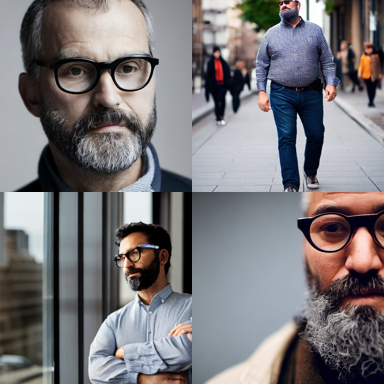

In [10]:
validation_prompts = [
    f'portrait photo of {config.trigger_token}, an adult man with round glasses, dark messy hair, thick eyebrows, and a salt and pepper beard, realistic skin texture, natural light, sharp focus',
    f'full body casual photo of {config.trigger_token} an adult man with round glasses and a salt and pepper beard, walking on a city street, realistic photography',
    f'photo of {config.trigger_token} an adult man with round glasses, dark messy hair, and a salt and pepper beard, in a modern office, soft window light',
    f'cinematic photo of {config.trigger_token} an adult man with round glasses and a salt and pepper beard, wearing a jacket at night, shallow depth of field',
]

negative_prompt = (
    'low quality, blurry, distorted face, deformed, bad anatomy, extra fingers, '
    'cartoon, painting, watermark, text'
)

for object_name in ['tokenizer', 'noise_scheduler', 'text_encoder', 'vae', 'unet', 'optimizer', 'lr_scheduler']:
    globals().pop(object_name, None)
if device.type == 'mps':
    torch.mps.empty_cache()
elif device.type == 'cuda':
    torch.cuda.empty_cache()

pipe = StableDiffusionPipeline.from_pretrained(
    config.model_id,
    torch_dtype=weight_dtype,
    safety_checker=None,
)
pipe.load_lora_weights(config.lora_dir)
pipe.to(device)
pipe.enable_attention_slicing()

sample_records = []
generator = torch.Generator(device='cpu').manual_seed(config.seed)

for index, prompt in enumerate(validation_prompts):
    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=config.validation_steps,
        guidance_scale=7.5,
        cross_attention_kwargs={'scale': config.lora_scale},
        width=config.resolution,
        height=config.resolution,
        generator=generator,
    ).images[0]
    image_path = config.samples_dir / f'sample_{index:02d}.png'
    image.save(image_path)
    sample_records.append({'image': str(image_path), 'prompt': prompt})
    print(f'Saved {image_path}')

(config.samples_dir / 'prompts.json').write_text(json.dumps(sample_records, indent=2), encoding='utf-8')
display(make_contact_sheet([Path(record['image']) for record in sample_records], thumb_size=192, columns=2))

globals().pop('pipe', None)
if device.type == 'mps':
    torch.mps.empty_cache()
elif device.type == 'cuda':
    torch.cuda.empty_cache()

## 7. Compute CLIP-I and CLIP-T

CLIP-I compares generated images with the prepared subject images. CLIP-T compares generated images with their prompts.

In [ ]:
clip_model_id = 'openai/clip-vit-base-patch32'
clip_model = CLIPModel.from_pretrained(clip_model_id).to(device)
clip_processor = CLIPProcessor.from_pretrained(clip_model_id)
clip_model.eval()


def load_rgb_images(paths: list[Path]) -> list[Image.Image]:
    images: list[Image.Image] = []
    for path in paths:
        with Image.open(path) as image:
            images.append(image.convert('RGB').copy())
    return images


def normalized_image_features(images: list[Image.Image]) -> torch.Tensor:
    inputs = clip_processor(images=images, return_tensors='pt').to(device)
    with torch.no_grad():
        features = clip_model.get_image_features(**inputs)
    # NẾU đầu ra là dataclass, lấy tensor pooler_output ra
    if not isinstance(features, torch.Tensor):
        features = features.pooler_output
    return F.normalize(features.float(), dim=-1)


def normalized_text_features(prompts: list[str]) -> torch.Tensor:
    inputs = clip_processor(text=prompts, padding=True, truncation=True, return_tensors='pt').to(device)
    with torch.no_grad():
        features = clip_model.get_text_features(**inputs)
    # NẾU đầu ra là dataclass, lấy tensor pooler_output ra
    if not isinstance(features, torch.Tensor):
        features = features.pooler_output
    return F.normalize(features.float(), dim=-1)


reference_paths = validated_images
generated_paths = [Path(record['image']) for record in sample_records]
generated_prompts = [record['prompt'] for record in sample_records]

reference_features = normalized_image_features(load_rgb_images(reference_paths))
generated_features = normalized_image_features(load_rgb_images(generated_paths))
prompt_features = normalized_text_features(generated_prompts)

reference_mean = F.normalize(reference_features.mean(dim=0, keepdim=True), dim=-1)
clip_i_to_mean = (generated_features @ reference_mean.T).squeeze(1)
clip_i_best_reference = (generated_features @ reference_features.T).max(dim=1).values
clip_t = (generated_features * prompt_features).sum(dim=1)

metric_rows = []
for index, image_path in enumerate(generated_paths):
    metric_rows.append({
        'image': str(image_path),
        'prompt': generated_prompts[index],
        'clip_i_mean_reference': float(clip_i_to_mean[index].cpu()),
        'clip_i_best_reference': float(clip_i_best_reference[index].cpu()),
        'clip_t': float(clip_t[index].cpu()),
    })

summary = {
    'clip_i_mean_reference_avg': sum(row['clip_i_mean_reference'] for row in metric_rows) / len(metric_rows),
    'clip_i_best_reference_avg': sum(row['clip_i_best_reference'] for row in metric_rows) / len(metric_rows),
    'clip_t_avg': sum(row['clip_t'] for row in metric_rows) / len(metric_rows),
    'rows': metric_rows,
}

json_path = config.metrics_dir / 'clip_metrics.json'
csv_path = config.metrics_dir / 'clip_metrics.csv'
json_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')

with csv_path.open('w', newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=metric_rows[0].keys())
    writer.writeheader()
    writer.writerows(metric_rows)

print(json.dumps({key: value for key, value in summary.items() if key != 'rows'}, indent=2))
print(f'Saved metrics to {json_path} and {csv_path}')

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 54148.14it/s]
